In [42]:
# !/usr/bin/env python3
# -*- coding: utf-8 -*-

# =====================
# General utilities
# =====================
import json
import os
import pickle
import time
from collections import Counter

# =====================
# Data handling & processing
# =====================
import numpy as np
import pandas as pd
from tqdm import tqdm

# =====================
# Visualization
# =====================
import matplotlib.pyplot as plt
import seaborn as sns

# =====================
# Machine Learning - Core scikit-learn
# =====================
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    mean_absolute_error, mean_squared_error, r2_score,
    root_mean_squared_error, roc_auc_score
)
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.svm import SVC, SVR

# =====================
# Machine Learning - Tree Boosting & advanced
# =====================
import xgboost as xg
import lightgbm as lgb
import catboost as cb

# =====================
# Deep Learning - TensorFlow / Keras
# =====================
import tensorflow as tf
from keras import regularizers
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.optimizers import Adam

# =====================
# Imbalanced data handling
# =====================
from imblearn.over_sampling import SMOTE

# =====================
# Optimization / AutoML
# =====================
import optuna

# =====================
# Feature importance & explainability
# =====================
import shap

# =====================
# Self Made Utilities
# =====================
from utils import *

# =====================
# Settings & reproducibility
# =====================
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

print("Libraries successfully loaded. Ready to go!")

Libraries successfully loaded. Ready to go!


In [29]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

feature_cols = [col for col in train.columns if col not in ['id', 'BeatsPerMinute']]
target_col = 'BeatsPerMinute'


🔗 CORRELATION ANALYSIS


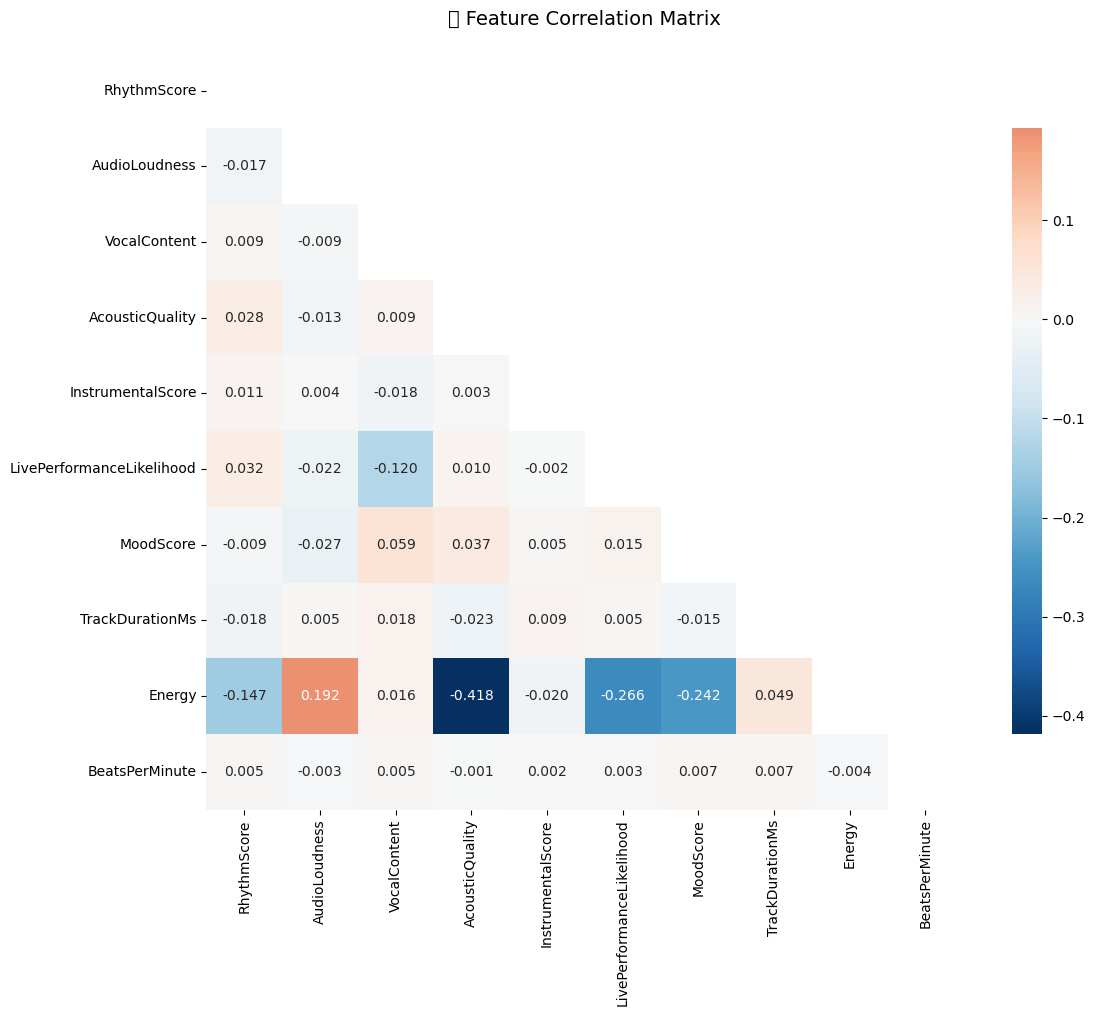


🎯 Features ranked by correlation with BPM:
 1. MoodScore                 | Correlation: 0.0071
 2. TrackDurationMs           | Correlation: 0.0066
 3. RhythmScore               | Correlation: 0.0054
 4. VocalContent              | Correlation: 0.0049
 5. Energy                    | Correlation: 0.0044
 6. LivePerformanceLikelihood | Correlation: 0.0035
 7. AudioLoudness             | Correlation: 0.0033
 8. InstrumentalScore         | Correlation: 0.0019
 9. AcousticQuality           | Correlation: 0.0008


In [30]:
print("\n" + "="*50)
print("🔗 CORRELATION ANALYSIS")
print("="*50)

# Calculate correlation matrix
correlation_matrix = train[feature_cols + [target_col]].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', 
            center=0, square=True, fmt='.3f', cbar_kws={"shrink": .8})
plt.title('🔗 Feature Correlation Matrix', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Feature importance based on correlation with target
target_correlations = correlation_matrix[target_col].drop(target_col).abs().sort_values(ascending=False)
print("\n🎯 Features ranked by correlation with BPM:")
for i, (feature, corr) in enumerate(target_correlations.items(), 1):
    print(f"{i:2d}. {feature:<25} | Correlation: {corr:.4f}")

In [ ]:
print("\n" + "="*50)
print("🧮 FEATURE ENGINEERING")
print("="*50)

def create_features(df):
    """Create additional features that might help predict BPM"""
    df = df.copy()
    
    # 1. Rhythm and Energy interactions
    df['RhythmEnergyProduct'] = df['RhythmScore'] * df['Energy']
    df['RhythmEnergyRatio'] = df['RhythmScore'] / (df['Energy'] + 1e-8)
    
    # 2. Audio characteristics
    df['LoudnessEnergyProduct'] = df['AudioLoudness'] * df['Energy']
    df['VocalInstrumentalRatio'] = df['VocalContent'] / (df['InstrumentalScore'] + 1e-8)
    
    # 3. Track duration features
    df['TrackDurationMin'] = df['TrackDurationMs'] / 60000  # Convert to minutes
    df['DurationMoodProduct'] = df['TrackDurationMin'] * df['MoodScore']
    
    # 4. Performance and quality features
    df['QualityPerformanceProduct'] = df['AcousticQuality'] * df['LivePerformanceLikelihood']
    
    # 5. Polynomial features for top correlated features
    top_3_features = target_correlations.head(3).index.tolist()
    for feature in top_3_features:
        df[f'{feature}_squared'] = df[feature] ** 2
        df[f'{feature}_sqrt'] = np.sqrt(np.abs(df[feature]))
    
    # 6. Binned features
    df['EnergyBin'] = pd.cut(df['Energy'], bins=5, labels=['VeryLow', 'Low', 'Medium', 'High', 'VeryHigh'])
    df['RhythmBin'] = pd.cut(df['RhythmScore'], bins=5, labels=['VeryLow', 'Low', 'Medium', 'High', 'VeryHigh'])
    
    # 7. Interaction between rhythm and tempo-related features
    df['RhythmDurationInteraction'] = df['RhythmScore'] * df['TrackDurationMin']

    # 8. Log transformations
    df['LogTrackDuration'] = np.log1p(df['TrackDurationMs'])
    df['LogLoudness'] = np.log1p(np.abs(df['AudioLoudness']) + 1e-8)  # Avoid log(0)
    
    # Clustering features (add musical genre-like groupings)
    # from sklearn.cluster import KMeans
    # cluster_features = ['Energy', 'RhythmScore', 'AudioLoudness', 'VocalContent']
    # kmeans = KMeans(n_clusters=5, random_state=42)
    # df['MusicCluster'] = kmeans.fit_predict(df[cluster_features])
    
    return df
    
# Apply feature engineering
train_engineered = create_features(train)
test_engineered = create_features(test)

# Get new feature columns
new_features = [col for col in train_engineered.columns if col not in train.columns]
print(f"✨ Created {len(new_features)} new features:")
for feature in new_features:
    print(f"   • {feature}")


🧮 FEATURE ENGINEERING
✨ Created 23 new features:
   • RhythmEnergyProduct
   • RhythmEnergyRatio
   • LoudnessEnergyProduct
   • VocalInstrumentalRatio
   • TrackDurationMin
   • DurationMoodProduct
   • QualityPerformanceProduct
   • MoodScore_squared
   • MoodScore_sqrt
   • TrackDurationMs_squared
   • TrackDurationMs_sqrt
   • RhythmScore_squared
   • RhythmScore_sqrt
   • EnergyBin
   • RhythmBin
   • RhythmDurationInteraction
   • LogTrackDuration
   • LogLoudness
   • FeatureMean
   • FeatureStd
   • FeatureSkew
   • Energy_Loudness_Ratio
   • Rhythm_Duration_Normalized


In [32]:
numerical_features = train_engineered.select_dtypes(include=[np.number]).columns.tolist()
feature_columns = [col for col in numerical_features if col not in ['id', 'BeatsPerMinute']]

In [33]:
# Prepare features for modeling
feature_columns = [col for col in numerical_features if col != target_col]
X = train_engineered[feature_columns]
y = train_engineered[target_col]

print(f"📊 Training with {len(feature_columns)} features")
print(f"🎯 Target variable: {target_col}")

# Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_test = create_features(test)[feature_columns]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

📊 Training with 31 features
🎯 Target variable: BeatsPerMinute


In [34]:
def objective_xgboost(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 5.0),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'random_state': 42,
        'eval_metric': 'rmse',
        'early_stopping_rounds': 100,
        'verbosity': 0,

        # GPU acceleration parameters
        'tree_method': 'gpu_hist',  # Use GPU histogram method
        'device': 'cuda',           # Specify CUDA device
    }

    cv_scores = []
    kf_tune = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, val_idx in kf_tune.split(X, y):
        X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]

        model = xg.XGBRegressor(**params)
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)

        pred = model.predict(X_val_fold)
        score = root_mean_squared_error(y_val_fold, pred)
        cv_scores.append(score)

    return np.mean(cv_scores)

print("➗ Tuning XGBoost parameters...")
study_xgboost = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))       
study_xgboost.optimize(objective_xgboost, n_trials=50)

best_xgboost_params = study_xgboost.best_params
print(f"Best XGBoost CV RMSE: {study_xgboost.best_value:.4f}")
print(f"Best XGBoost params: {best_xgboost_params}")

[I 2025-09-24 13:50:25,120] A new study created in memory with name: no-name-91f84a8a-4401-4910-b4ee-e4ce14827a66


➗ Tuning XGBoost parameters...


[I 2025-09-24 13:50:32,365] Trial 0 finished with value: 26.462705197382366 and parameters: {'n_estimators': 193, 'learning_rate': 0.09556428757689246, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.5624074561769746, 'colsample_bytree': 0.562397808134481, 'reg_alpha': 0.21035886311957896, 'reg_lambda': 4.46470458309974, 'gamma': 0.6011150117432088}. Best is trial 0 with value: 26.462705197382366.
[I 2025-09-24 13:50:45,336] Trial 1 finished with value: 26.46111143494931 and parameters: {'n_estimators': 357, 'learning_rate': 0.011852604486622221, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.5849356442713105, 'colsample_bytree': 0.5727299868828403, 'reg_alpha': 0.4484685687215243, 'reg_lambda': 2.216968971838151, 'gamma': 0.5247564316322378}. Best is trial 1 with value: 26.46111143494931.
[I 2025-09-24 13:50:52,251] Trial 2 finished with value: 26.460444043021916 and parameters: {'n_estimators': 222, 'learning_rate': 0.036210622617823776, 'max_depth': 6, 'min_child_weight

Best XGBoost CV RMSE: 26.4602
Best XGBoost params: {'n_estimators': 457, 'learning_rate': 0.026795109277633986, 'max_depth': 4, 'min_child_weight': 2, 'subsample': 0.755008650200686, 'colsample_bytree': 0.5377692956708234, 'reg_alpha': 1.6209567175589383, 'reg_lambda': 3.901897324133343, 'gamma': 0.2927907759783605}


In [35]:
def objective_lightgbm(trial):
    # LightGBM-specific parameter space for regression
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 500),       
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),   
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'num_leaves': trial.suggest_int('num_leaves', 31, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 2.0),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        'random_state': 42,
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'early_stopping_rounds': 100,

        'device': 'gpu',
        'gpu_platform_id': 0,
        'gpu_device_id': 0,
    }

    cv_scores = []
    kf_tune = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, val_idx in kf_tune.split(X, y):
        X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)])

        pred = model.predict(X_val_fold)
        score = root_mean_squared_error(y_val_fold, pred)
        cv_scores.append(score)

    return np.mean(cv_scores)

print("Tuning LightGBM parameters...")
study_lightgbm = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_lightgbm.optimize(objective_lightgbm, n_trials=50)

best_lightgbm_params = study_lightgbm.best_params
print(f"Best LightGBM CV RMSE: {study_lightgbm.best_value:.4f}")
print(f"Best LightGBM params: {best_lightgbm_params}")

[I 2025-09-24 13:55:49,469] A new study created in memory with name: no-name-36f412fe-edbf-46e8-bf4d-8abe7c3acdfc


Tuning LightGBM parameters...


[I 2025-09-24 13:56:01,665] Trial 0 finished with value: 26.461082498339245 and parameters: {'n_estimators': 193, 'learning_rate': 0.09556428757689246, 'max_depth': 7, 'num_leaves': 89, 'min_child_samples': 32, 'subsample': 0.7467983561008608, 'colsample_bytree': 0.7174250836504598, 'reg_alpha': 1.7323522915498704, 'reg_lambda': 1.2022300234864176, 'min_split_gain': 0.7080725777960455}. Best is trial 0 with value: 26.461082498339245.
[I 2025-09-24 13:56:05,878] Trial 1 finished with value: 26.460307482752633 and parameters: {'n_estimators': 20, 'learning_rate': 0.0972918866945795, 'max_depth': 7, 'num_leaves': 51, 'min_child_samples': 34, 'subsample': 0.7550213529560301, 'colsample_bytree': 0.7912726728878613, 'reg_alpha': 1.0495128632644757, 'reg_lambda': 0.8638900372842315, 'min_split_gain': 0.2912291401980419}. Best is trial 1 with value: 26.460307482752633.
[I 2025-09-24 13:56:15,595] Trial 2 finished with value: 26.459609503714013 and parameters: {'n_estimators': 310, 'learning_ra

Best LightGBM CV RMSE: 26.4593
Best LightGBM params: {'n_estimators': 433, 'learning_rate': 0.06609683141448022, 'max_depth': 4, 'num_leaves': 37, 'min_child_samples': 45, 'subsample': 0.7975549966080241, 'colsample_bytree': 0.9188818535014192, 'reg_alpha': 1.2751149427104262, 'reg_lambda': 1.774425485152653, 'min_split_gain': 0.4722149251619493}


In [36]:
def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_seed': 42,
        'eval_metric': 'RMSE',
        'early_stopping_rounds': 100,
        'verbose': False,
        
        'task_type': 'GPU',  # Use GPU for training
        'devices': '0:1'     # Specify GPU devices
    }

    cv_scores = []
    kf_tune = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, val_idx in kf_tune.split(X, y):
        X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]

        model = cb.CatBoostRegressor(**params)
        model.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold))

        pred = model.predict(X_val_fold)
        score = root_mean_squared_error(y_val_fold, pred)
        cv_scores.append(score)

    return np.mean(cv_scores)

print("➗ Tuning CatBoost parameters...")
study_catboost = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_catboost.optimize(objective_catboost, n_trials=50)

best_catboost_params = study_catboost.best_params
print(f"Best CatBoost params: {best_catboost_params}")
print(f"Best CatBoost CV RMSE: {study_catboost.best_value:.4f}")

[I 2025-09-24 14:02:22,546] A new study created in memory with name: no-name-63e88423-b43a-4df9-b693-d5ce9789c7ad


➗ Tuning CatBoost parameters...


[I 2025-09-24 14:02:29,794] Trial 0 finished with value: 26.46067841746834 and parameters: {'iterations': 437, 'learning_rate': 0.09556428757689246, 'depth': 8, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66}. Best is trial 0 with value: 26.46067841746834.
[I 2025-09-24 14:02:46,855] Trial 1 finished with value: 26.459670724505884 and parameters: {'iterations': 240, 'learning_rate': 0.015227525095137952, 'depth': 9, 'l2_leaf_reg': 6.41003510568888, 'border_count': 190}. Best is trial 1 with value: 26.459670724505884.
[I 2025-09-24 14:02:54,650] Trial 2 finished with value: 26.46104649941759 and parameters: {'iterations': 118, 'learning_rate': 0.0972918866945795, 'depth': 9, 'l2_leaf_reg': 2.9110519961044856, 'border_count': 72}. Best is trial 1 with value: 26.459670724505884.
[I 2025-09-24 14:03:02,672] Trial 3 finished with value: 26.459707519560766 and parameters: {'iterations': 265, 'learning_rate': 0.0373818018663584, 'depth': 7, 'l2_leaf_reg': 4.887505167779041, 'border_coun

Best CatBoost params: {'iterations': 771, 'learning_rate': 0.039065982569865626, 'depth': 5, 'l2_leaf_reg': 5.676518482917524, 'border_count': 134}
Best CatBoost CV RMSE: 26.4590


In [44]:
def generate_stack(
    base_models,
    X, y,
    X_test,
    meta_model=None,
    folds=5,
    seed=42,
    eval_metric=root_mean_squared_error
):
    """
    Train a stacking ensemble.

    Parameters:
    - base_models: list of sklearn-like models (must implement fit & predict)
    - X, y: training data
    - X_test: test data (for generating meta features)
    - meta_model: sklearn-like model for meta learning (default: LinearRegression)
    - folds: number of KFold splits
    - seed: random seed for reproducibility
    - eval_metric: function to evaluate final stacked predictions (default: RMSE)

    Returns:
    - meta_model: trained meta-model
    - meta_features_train: level-one train predictions
    - meta_features_test: level-one test predictions
    - final_score: score computed by eval_metric
    - train_preds: meta-model predictions on training data (for evaluation)
    - test_preds: meta-model predictions on test data (for submission)
    """

    n_models = len(base_models)
    meta_features_train = np.zeros((len(X), n_models))
    meta_features_test = np.zeros((len(X_test), n_models))
    
    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)

    print(f"Starting stacking with {n_models} base models and {folds}-fold CV...")
    
    for i, model in enumerate(base_models):
        print(f"\nTraining model {i+1}/{n_models}: {model.__class__.__name__}")
        
        oof = np.zeros(len(X))
        preds = np.zeros(len(X_test))
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model.fit(X_train, y_train)
            oof[val_idx] = model.predict(X_val)
            preds += model.predict(X_test) / folds

            fold_score = eval_metric(y_val, oof[val_idx])
            print(f"  Fold {fold+1} {eval_metric.__name__}: {fold_score:.4f}")

        meta_features_train[:, i] = oof
        meta_features_test[:, i] = preds
    
    # Use default meta model if none provided
    if meta_model is None:
        meta_model = LinearRegression()

    print(f"\nFitting meta-model: {meta_model.__class__.__name__}")
    meta_model.fit(meta_features_train, y)
    
    # Generate predictions for both train (evaluation) and test (submission)
    train_preds = meta_model.predict(meta_features_train)
    test_preds = meta_model.predict(meta_features_test)
    
    final_score = eval_metric(y, train_preds)
    print(f"\nFinal cross-validation {eval_metric.__name__}: {final_score:.4f}")

    return meta_model, meta_features_train, meta_features_test, final_score, train_preds, test_preds

In [45]:
# Usage
from sklearn.linear_model import Ridge

base_models = [
    xg.XGBRegressor(**best_xgboost_params, random_state=42, n_jobs=-1),
    lgb.LGBMRegressor(**best_lightgbm_params, random_state=42, n_jobs=-1),
    cb.CatBoostRegressor(**best_catboost_params, random_state=42, verbose=0)
]

meta_model, meta_features_train, meta_features_test, final_score, train_preds, test_preds = generate_stack(
    base_models, X, y, X_test, 
    meta_model=Ridge(), 
    folds=5, 
    seed=42, 
    eval_metric=root_mean_squared_error
)

# ✅ CORRECT: Use test_preds for submission
test_predictions = np.clip(test_preds, 60, 200)

submission = pd.DataFrame({
    'id': test['id'],
    'BeatsPerMinute': test_predictions
})

print(f"\n✅ Submission created with {len(submission)} predictions")
print(f"Prediction range: {test_predictions.min():.2f} - {test_predictions.max():.2f}")

submission.to_csv("alpha_romeo.csv", index=False)

Starting stacking with 3 base models and 5-fold CV...

Training model 1/3: XGBRegressor
  Fold 1 root_mean_squared_error: 26.4433
  Fold 2 root_mean_squared_error: 26.4885
  Fold 3 root_mean_squared_error: 26.5260
  Fold 4 root_mean_squared_error: 26.4453
  Fold 5 root_mean_squared_error: 26.4104

Training model 2/3: LGBMRegressor
  Fold 1 root_mean_squared_error: 26.4520
  Fold 2 root_mean_squared_error: 26.4970
  Fold 3 root_mean_squared_error: 26.5345
  Fold 4 root_mean_squared_error: 26.4563
  Fold 5 root_mean_squared_error: 26.4220

Training model 3/3: CatBoostRegressor
  Fold 1 root_mean_squared_error: 26.4429
  Fold 2 root_mean_squared_error: 26.4872
  Fold 3 root_mean_squared_error: 26.5277
  Fold 4 root_mean_squared_error: 26.4472
  Fold 5 root_mean_squared_error: 26.4123

Fitting meta-model: Ridge

Final cross-validation root_mean_squared_error: 26.4609

✅ Submission created with 174722 predictions
Prediction range: 113.93 - 125.09


Stacking OOF RMSE: 26.4665

26.4687


Stacking Validation RMSE: 26.4387

Stacker CV RMSE: 26.4665

In [46]:
submission.head()

,id,BeatsPerMinute
0,524164,119.335383
1,524165,118.342558
2,524166,120.133692
3,524167,118.938178
4,524168,119.911148
